In [ ]:

# libraries for data wrangling
import pandas as pd
import numpy as np

# library for plotting
from plotnine import *
import matplotlib.pyplot as plt

# ML workflow packages
from sklearn.model_selection import train_test_split,validation_curve
from sklearn.metrics import classification_report, roc_curve, auc,r2_score,mean_squared_error
from sklearn.preprocessing import StandardScaler,LabelEncoder

# ML models
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor




#### Supervised Machine Learning Model Workflow
##### 1. Load Data
##### 2. Visualize, Clean, and Preprocess Data
##### 3. Create Model Instance
##### 4. Fit Model on Data
##### 5. Make Predictions and Evaluate Model 

In [54]:
# 1. Load Data
df = pd.read_csv("https://raw.githubusercontent.com/cristobalvch/Spotify-Machine-Learning/refs/heads/master/data/data_moods.csv")
df.head()

,name,album,artist,id,release_date,popularity,length,danceability,acousticness,energy,instrumentalness,liveness,valence,loudness,speechiness,tempo,key,time_signature,mood
0,1999,1999,Prince,2H7PHVdQ3mXqEHXcvclTB0,1982-10-27,68,379266,0.866,0.13700,0.730,0.000000,0.0843,0.625,-8.201,0.0767,118.523,5,4,Happy
1,23,23,Blonde Redhead,4HIwL9ii9CcXpTOTzMq0MP,2007-04-16,43,318800,0.381,0.01890,0.832,0.196000,0.1530,0.166,-5.069,0.0492,120.255,8,4,Sad
2,9 Crimes,9,Damien Rice,5GZEeowhvSieFDiR8fQ2im,2006-11-06,60,217946,0.346,0.91300,0.139,0.000077,0.0934,0.116,-15.326,0.0321,136.168,0,4,Sad
3,99 Luftballons,99 Luftballons,Nena,6HA97v4wEGQ5TUClRM0XLc,1984-08-21,2,233000,0.466,0.08900,0.438,0.000006,0.1130,0.587,-12.858,0.0608,193.100,4,4,Happy
4,A Boy Brushed Red Living In Black And White,They're Only Chasing Safety,Underoath,47IWLfIKOKhFnz1FUEUIkE,2004-01-01,60,268000,0.419,0.00171,0.932,0.000000,0.1370,0.445,-3.604,0.1060,169.881,1,4,Energetic


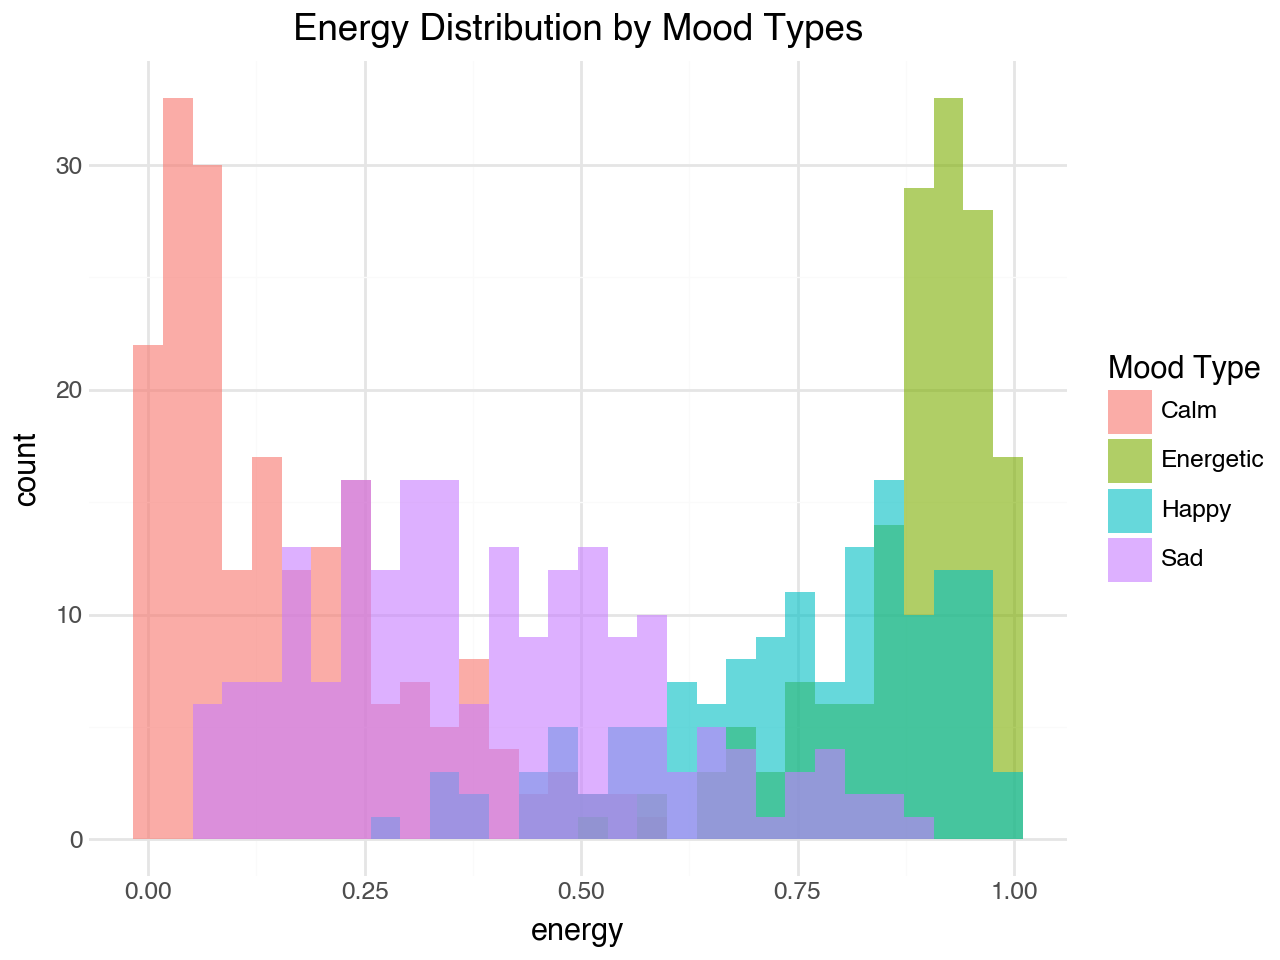

In [55]:
# 2. Visualize, Clean, and Preprocess Data

# use plotnine's ggplot function to visualize the distribution of energy across moods
(
    ggplot(df, aes(x='energy', fill='factor(mood)'))
    + geom_histogram(bins=30, alpha=0.6, position='identity')
    + labs(title='Energy Distribution by Mood Types', fill='Mood Type')
    + theme_minimal()
)

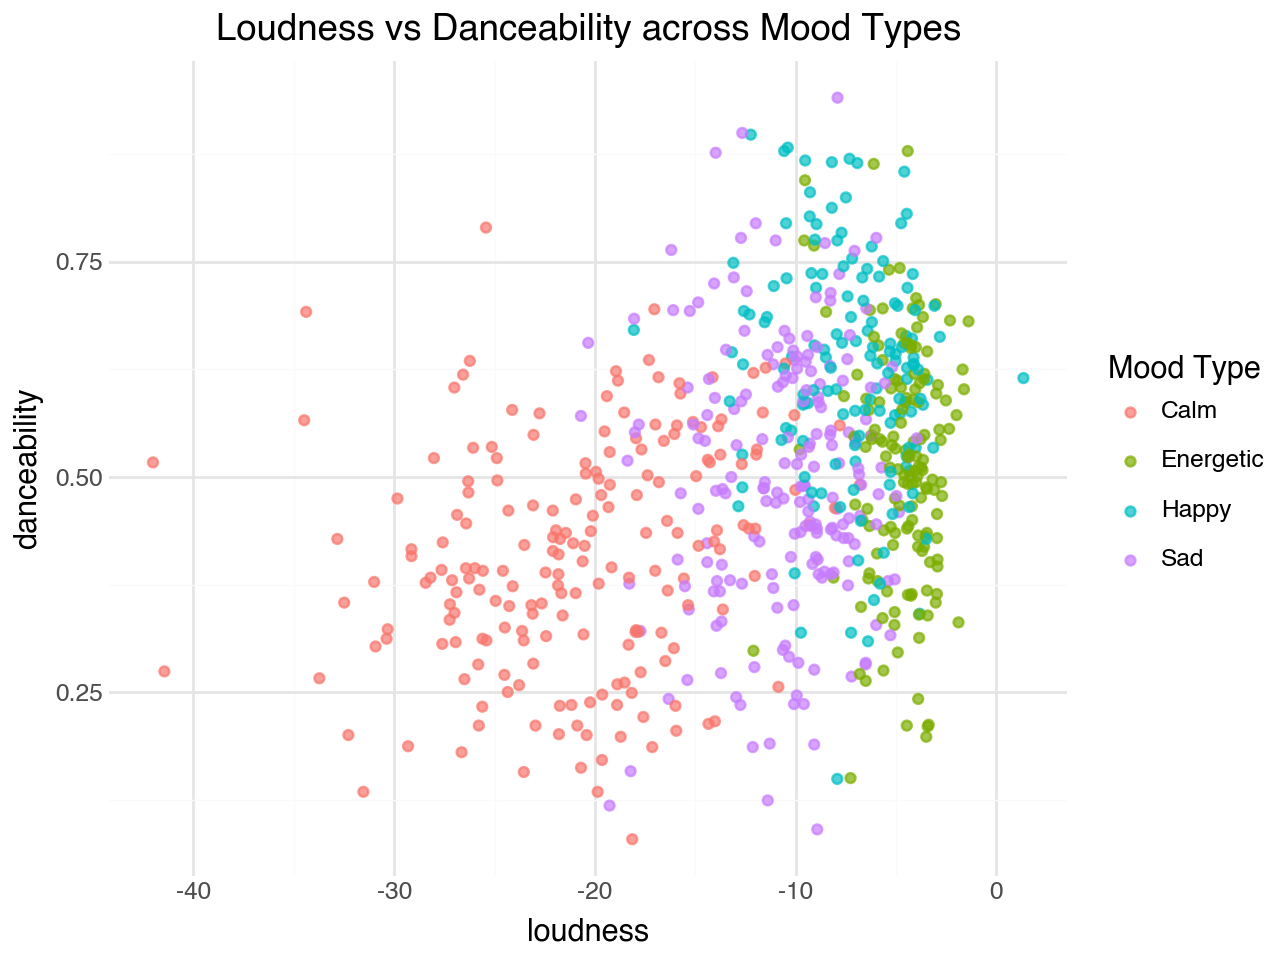

In [56]:
# scatter plot of two features color-coded by target variable
(
    ggplot(df, aes(x='loudness', y='danceability', color='factor(mood)'))
+ geom_point(alpha=0.7)
    + labs(title='Loudness vs Danceability across Mood Types', color='Mood Type')
    + theme_minimal()
)

Let's drop the Happy and Sad classes to make it a binary classification problem

In [57]:
df = df[(df['mood'] == 'Calm') | (df['mood'] == 'Energetic')]

In [58]:
df['mood'].value_counts()

mood
Calm         195
Energetic    154
Name: count, dtype: int64

In [59]:
# set X and y
X = df[['danceability','liveness','length','popularity','acousticness','liveness','tempo','time_signature']]
y = df['mood']

In [60]:
X

,danceability,liveness,length,popularity,acousticness,liveness,tempo,time_signature
4,0.419,0.1370,268000,60,0.00171,0.1370,169.881,4
5,0.394,0.1050,129410,27,0.99500,0.1050,71.241,5
6,0.504,0.1150,141888,29,0.99400,0.1150,134.209,4
8,0.603,0.6710,184640,68,0.01440,0.6710,133.063,4
9,0.331,0.7320,189200,0,0.00344,0.7320,175.009,4
...,...,...,...,...,...,...,...,...
675,0.609,0.1120,144434,48,0.98500,0.1120,111.966,4
678,0.259,0.0923,254440,35,0.95600,0.0923,123.693,4
679,0.604,0.1050,159840,36,0.98600,0.1050,117.781,4
681,0.402,0.0921,123066,36,0.96100,0.0921,129.736,3


In [61]:
# one-hot encode time_signature
X = pd.get_dummies(X, columns=['time_signature'])

In [62]:
y

4      Energetic
5           Calm
6           Calm
8      Energetic
9      Energetic
         ...    
675         Calm
678         Calm
679         Calm
681         Calm
685         Calm
Name: mood, Length: 349, dtype: object

In [63]:
# split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2)

In [64]:
# standardization applied to features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

First, we train a Decision Tree Classifier to predict mood type

In [65]:
# 3. Create Model Instance
dt_classifier = DecisionTreeClassifier(max_depth=5, random_state=42)

In [66]:
# 4. Fit Model on Data
dt_classifier.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [67]:
# 5. Evaluate Model
y_pred = dt_classifier.predict(X_test)
print(f"\n\n Decision Tree Classification Report")
print(classification_report(y_test, y_pred)) # produce classification report



 Decision Tree Classification Report
              precision    recall  f1-score   support

        Calm       0.97      0.90      0.94        40
   Energetic       0.88      0.97      0.92        30

    accuracy                           0.93        70
   macro avg       0.93      0.93      0.93        70
weighted avg       0.93      0.93      0.93        70



In [68]:
# 3. Create Model Instance
logistic_model = LogisticRegression()

# 4. Fit Model on Data
logistic_model.fit(X_train, y_train)

# 5. Evaluate Model
y_pred = logistic_model.predict(X_test)
print(f"\n\n Decision Tree Classification Report")
print(classification_report(y_test, y_pred)) # produce classification report




 Decision Tree Classification Report
              precision    recall  f1-score   support

        Calm       1.00      0.95      0.97        40
   Energetic       0.94      1.00      0.97        30

    accuracy                           0.97        70
   macro avg       0.97      0.97      0.97        70
weighted avg       0.97      0.97      0.97        70



We can also generate the ROC curve

In [69]:
le = LabelEncoder()
y_true_num = le.fit_transform(y_test)  # e.g., Calm → 0, Energetic → 1

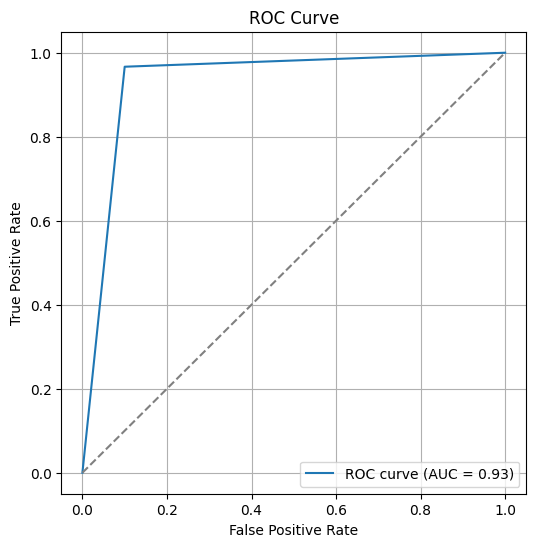

In [70]:
y_proba = dt_classifier.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_true_num, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

Repeat the ML workflow to train a Decision Tree Regressor and a Linear Regression model, to predict energy.
Generate a correlation matrix first to exclude features that may be too linearly related. Note that evaluation of a model that predicts a continuous value may not be done using Accuracy, Recall, or Precision. 

In [71]:
def generate_matrix(corr_matrix):
    plt.figure(figsize=(8, 6))
    plt.imshow(corr_matrix, cmap='coolwarm', interpolation='none', aspect='auto')
    plt.colorbar(label='Correlation Coefficient')
    plt.xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=45)
    plt.yticks(range(len(corr_matrix)), corr_matrix.columns)

    # Add correlation coefficients on heatmap
    for i in range(len(corr_matrix)):
        for j in range(len(corr_matrix)):
            plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                    ha='center', va='center', color='black')

    plt.title('Correlation Matrix')
    plt.tight_layout()
    plt.show()


In [72]:
# extract numerical features + energy from data frame

features = ['danceability','popularity','length','acousticness',\
            'energy','instrumentalness','liveness','valence','loudness',\
            'speechiness','tempo']

In [73]:
# use df_name.corr() function to get correlation matrix
corr_matrix = df[features].corr()


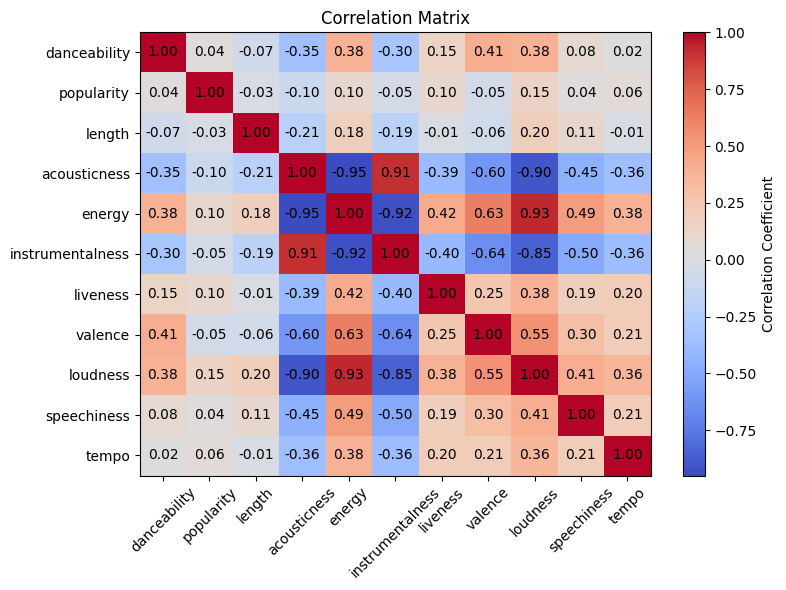

In [74]:
# use the generate_matrix() function to visualize the matrix
generate_matrix(corr_matrix)

In [77]:
# use your selected features to train the two models to predict energy

# features previously contained energy so we will remove it from the list
features.remove('energy')
X = df[features]
y = df['energy']

# split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2)

# standardization applied to features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Decision Tree Regressor
dt_regressor = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_regressor.fit(X_train, y_train)

# Train Linear Regression
linear_regressor = LinearRegression()
linear_regressor.fit(X_train, y_train)



,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [78]:
from sklearn.metrics import r2_score

# Decision Tree Regressor accuracy (R^2 score)
dt_r2 = r2_score(y_test, dt_regressor.predict(X_test))
print(f"Decision Tree Regressor R^2 score: {dt_r2:.3f}")

# Linear Regression accuracy (R^2 score)
lr_r2 = r2_score(y_test, linear_regressor.predict(X_test))
print(f"Linear Regression R^2 score: {lr_r2:.3f}")

Decision Tree Regressor R^2 score: 0.864
Linear Regression R^2 score: 0.945


In [79]:
from sklearn.metrics import mean_squared_error

# Decision Tree Regressor MSE
dt_mse = mean_squared_error(y_test, dt_regressor.predict(X_test))
print(f"Decision Tree Regressor MSE: {dt_mse:.4f}")

# Linear Regression MSE
lr_mse = mean_squared_error(y_test, linear_regressor.predict(X_test))
print(f"Linear Regression MSE: {lr_mse:.4f}")

Decision Tree Regressor MSE: 0.0199
Linear Regression MSE: 0.0080


Let's now look at a Clustering model

In [80]:
# library for generating classification data example
from sklearn.datasets import make_classification
from sklearn.cluster import KMeans

In [83]:
# 1. Load Data
# we will use the Spotify dataset again for this exercise but we will drop the mood column
df = pd.read_csv("https://raw.githubusercontent.com/cristobalvch/Spotify-Machine-Learning/refs/heads/master/data/data_moods.csv")

df = df.drop(columns=['mood'])

features = ['energy','valence']

X = df[features]

In [84]:
# 2. Visualize, Clean, and Preprocess Data

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



In [85]:
# 3. Create Model Instance
# 4. Fit Model on Data
sse_values = []

k_values = range(2, 20)

for k in k_values:
    km = KMeans(n_clusters=k)
    km.fit(X_scaled)
    sse_values.append(km.inertia_)
    


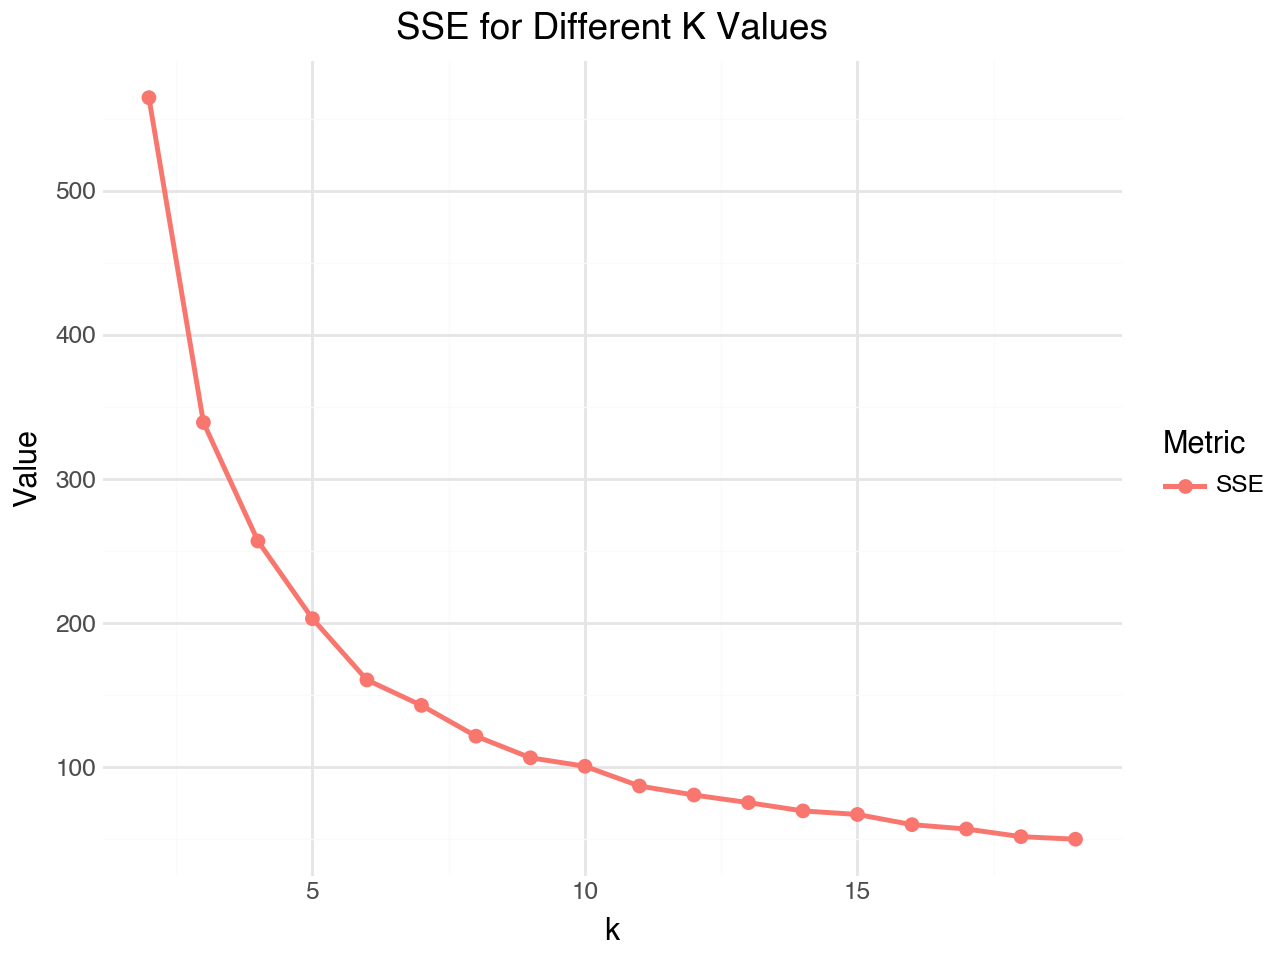

In [44]:
evaluation_df = pd.DataFrame({'k': k_values,
'SSE': sse_values})


(
    ggplot(evaluation_df, aes(x='k'))
    + geom_line(aes(y='SSE', color='"SSE"'), size=1)
    + geom_point(aes(y='SSE', color='"SSE"'), size=2)
    + labs(title='SSE for Different K Values', y='Value', color='Metric')
    + theme_minimal()
)

The plot above indicates that a k value of 5 would be most optimal for defining clusters in the data.

Let's reload our data and see how different values of mood are associated with a song's energy and valence

In [87]:
# 1. Load Data
df = pd.read_csv("https://raw.githubusercontent.com/cristobalvch/Spotify-Machine-Learning/refs/heads/master/data/data_moods.csv")
df.head()

,name,album,artist,id,release_date,popularity,length,danceability,acousticness,energy,instrumentalness,liveness,valence,loudness,speechiness,tempo,key,time_signature,mood
0,1999,1999,Prince,2H7PHVdQ3mXqEHXcvclTB0,1982-10-27,68,379266,0.866,0.13700,0.730,0.000000,0.0843,0.625,-8.201,0.0767,118.523,5,4,Happy
1,23,23,Blonde Redhead,4HIwL9ii9CcXpTOTzMq0MP,2007-04-16,43,318800,0.381,0.01890,0.832,0.196000,0.1530,0.166,-5.069,0.0492,120.255,8,4,Sad
2,9 Crimes,9,Damien Rice,5GZEeowhvSieFDiR8fQ2im,2006-11-06,60,217946,0.346,0.91300,0.139,0.000077,0.0934,0.116,-15.326,0.0321,136.168,0,4,Sad
3,99 Luftballons,99 Luftballons,Nena,6HA97v4wEGQ5TUClRM0XLc,1984-08-21,2,233000,0.466,0.08900,0.438,0.000006,0.1130,0.587,-12.858,0.0608,193.100,4,4,Happy
4,A Boy Brushed Red Living In Black And White,They're Only Chasing Safety,Underoath,47IWLfIKOKhFnz1FUEUIkE,2004-01-01,60,268000,0.419,0.00171,0.932,0.000000,0.1370,0.445,-3.604,0.1060,169.881,1,4,Energetic


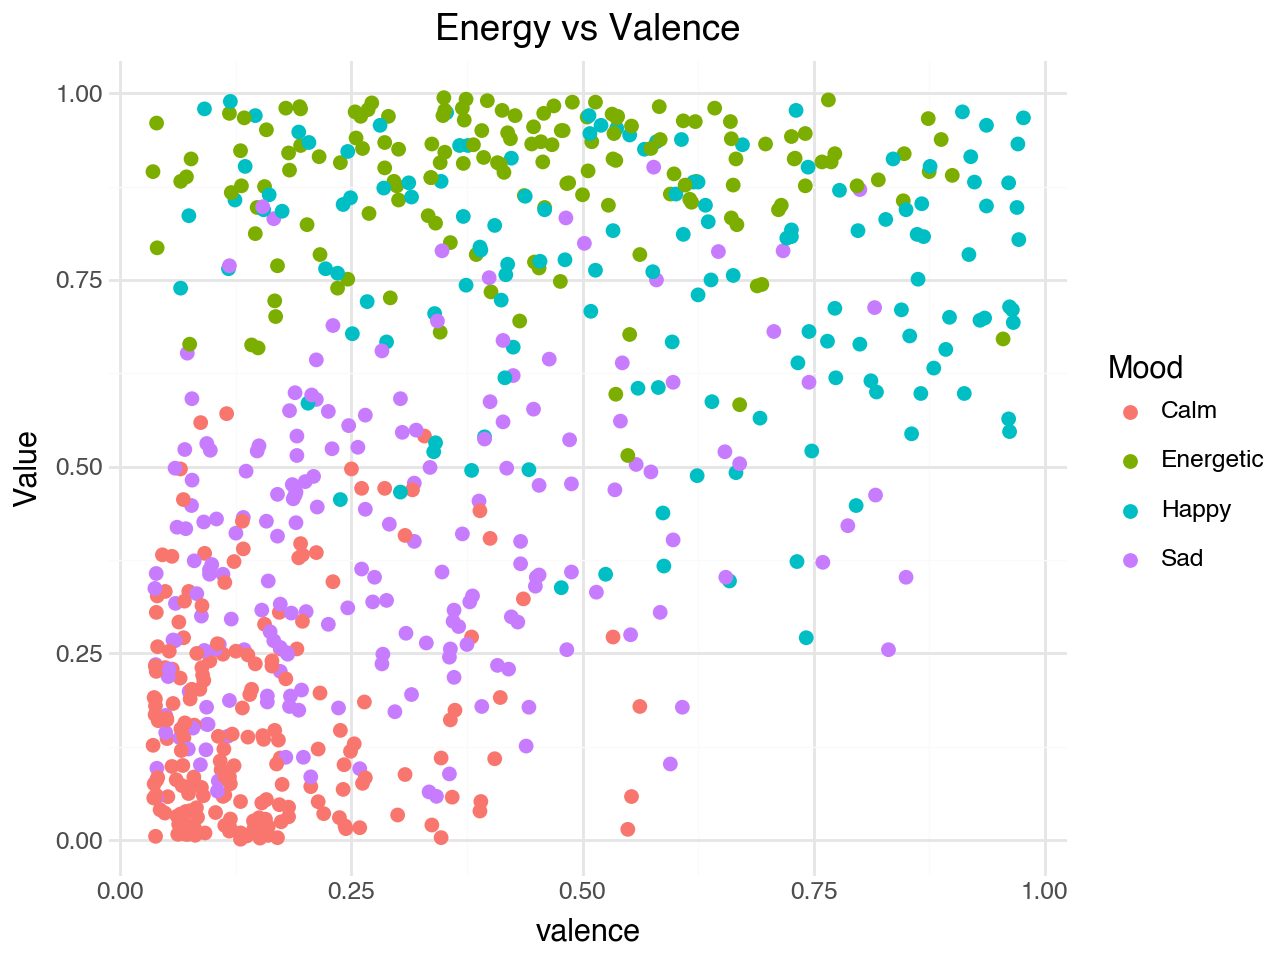

In [88]:
(
    ggplot(df)
    + geom_point(aes(x='valence',y='energy', color='mood'), size=2)
    + labs(title='Energy vs Valence', y='Value', color='Mood')
    + theme_minimal()
)

While the optimal k value for the k-Means algorithm was 5, we will test both 5 and 4 to see how they represent the 4 moods in our data

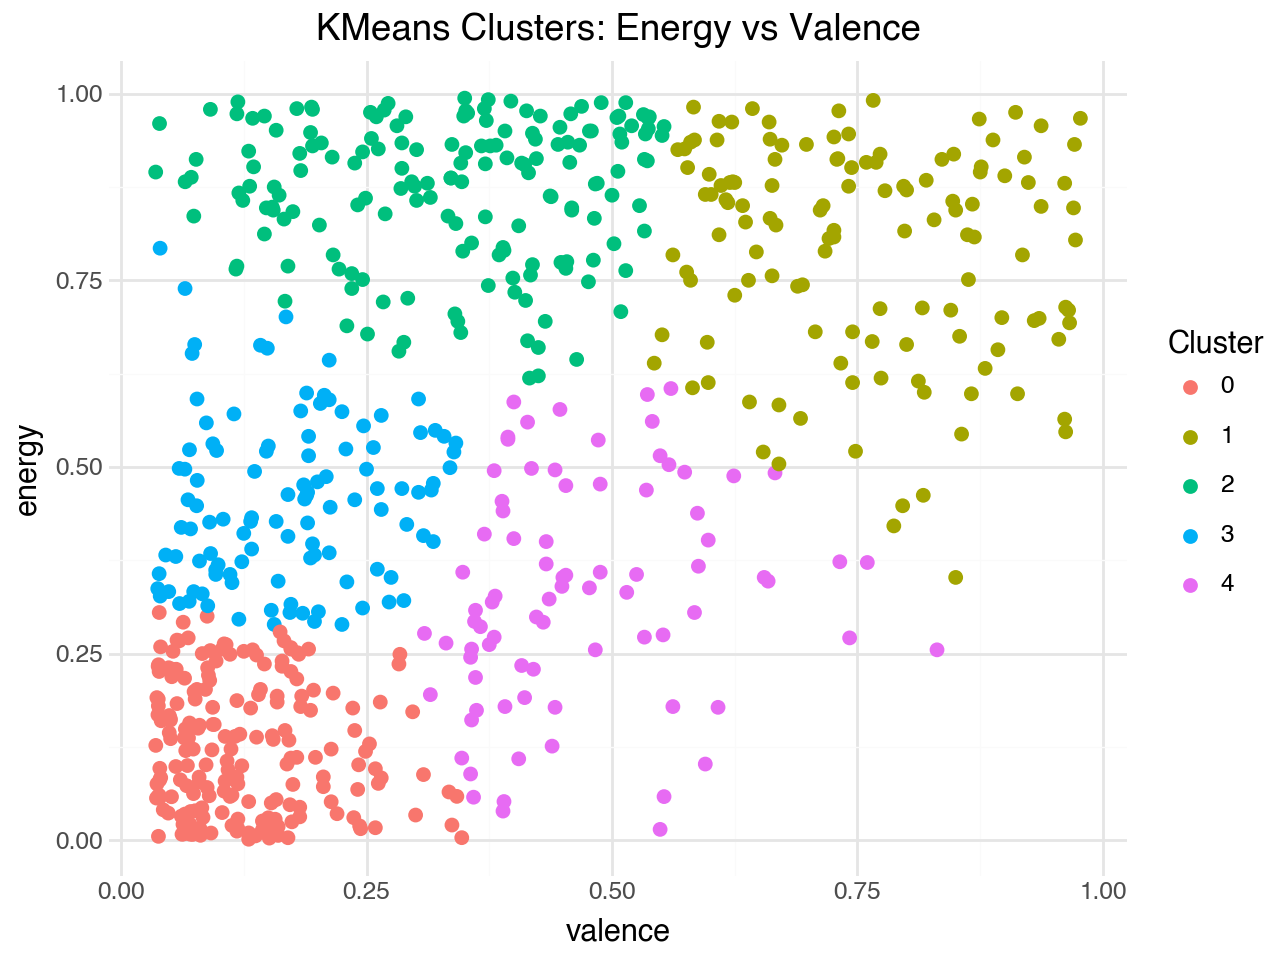

In [ ]:
# k-Means with k = 5
km = KMeans(n_clusters=5)
km.fit(X_scaled)

# Get cluster predictions
df['cluster'] = km.predict(X_scaled)

# Plot clusters using plotnine
(
    ggplot(df, aes(x='valence', y='energy', color='factor(cluster)'))
    + geom_point(size=2)
    + labs(title='KMeans Clusters: Energy vs Valence', color='Cluster')
    + theme_minimal()
)

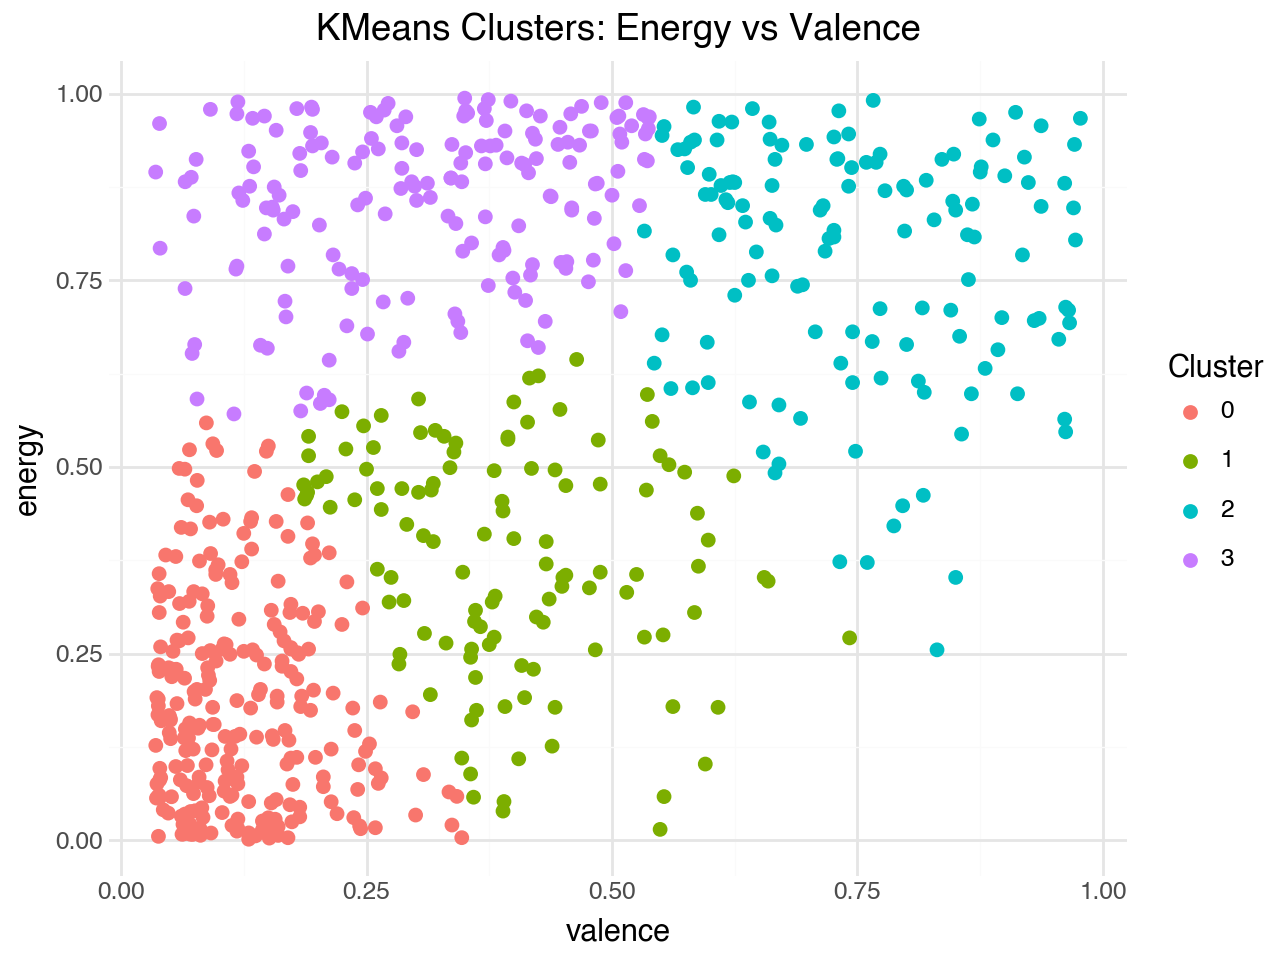

In [91]:
# k-Means with k = 4
km = KMeans(n_clusters=4)
km.fit(X_scaled)

# Get cluster predictions
df['cluster'] = km.predict(X_scaled)

# Plot clusters using plotnine
(
    ggplot(df, aes(x='valence', y='energy', color='factor(cluster)'))
    + geom_point(size=2)
    + labs(title='KMeans Clusters: Energy vs Valence', color='Cluster')
    + theme_minimal()
)

The separation of our clusters may not be obvious in a 2D plot. Instead, we will try a 3D plot to observe the clusters produced by the k-Means model. 

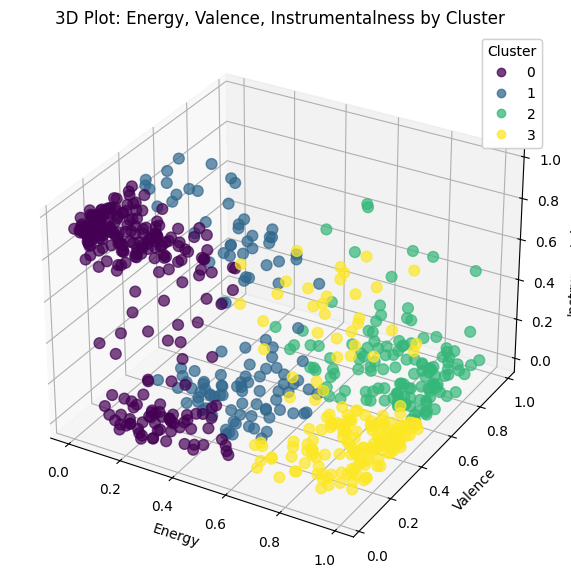

In [92]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Ensure 'cluster' column exists in df, and columns 'energy', 'valence', 'instrumentalness' are present
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df['energy'],
    df['valence'],
    df['instrumentalness'],
    c=df['cluster'],
    cmap='viridis',
    s=60,
    alpha=0.7
)

ax.set_xlabel('Energy')
ax.set_ylabel('Valence')
ax.set_zlabel('Instrumentalness')
ax.set_title('3D Plot: Energy, Valence, Instrumentalness by Cluster')

legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)
plt.show()

Our clusters do create a form of separation of the data points. Our next topic will be to understand how to generate the best separations between classes in our data.